In [1]:
import sys
sys.path.append("/Users/sophia/Desktop/Fundamentals_of_Bioinformatics/BioInfoFinalProject")

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import anndata as ad
import seaborn as sns
import scanpy as sc
import warnings
warnings.filterwarnings("ignore", category = UserWarning, module = "openpyxl")
from trajectory_inference.Laplacian_Eigenmaps import fullLaplacian, rankPseudo
from data.preprocess.preprocess import revelio_like_preprocess, loadData, readMarkerSets

In [3]:
# loading in data and gene phase markers
countdf = loadData("../data/GSE142277/GSM4224315_out_gene_exon_tagged.dge_exonssf002_WT.txt")
marker_dict = readMarkerSets("../data/GSE142277/revelio_gene_sets.csv", format = "csv")

In [4]:
# processing data with revelio like processing function
adata = revelio_like_preprocess(countdf, marker_dict)

G1.S 132 ['ABCA7', 'ACD', 'ACYP1', 'ADAMTS1', 'ADCK2', 'ADCY6', 'ANKRD10', 'AP4B1', 'APEX2', 'ARGLU1']
S 147 ['ABCC2', 'ABCC5', 'ABHD10', 'ACPP', 'ADAM22', 'ANKRD18A', 'ANKRD36', 'ARHGAP42', 'ASF1B', 'ATAD2']
G2 160 ['ALKBH1', 'ANLN', 'AP3D1', 'ARHGAP11B', 'ARHGAP19', 'ARL4A', 'ARMC1', 'ASXL1', 'ATL2', 'AURKB']
G2.M 186 ['AHI1', 'AKIRIN2', 'ANKRD40', 'ANLN', 'ANP32B', 'ANP32E', 'ARHGAP19', 'ARHGDIB', 'ARL6IP1', 'ASXL1']
M.G1 127 ['AFAP1', 'AGFG1', 'AGPAT3', 'AKAP13', 'AMD1', 'ANP32E', 'ANTXR1', 'BAG3', 'BTBD3', 'C3orf62']


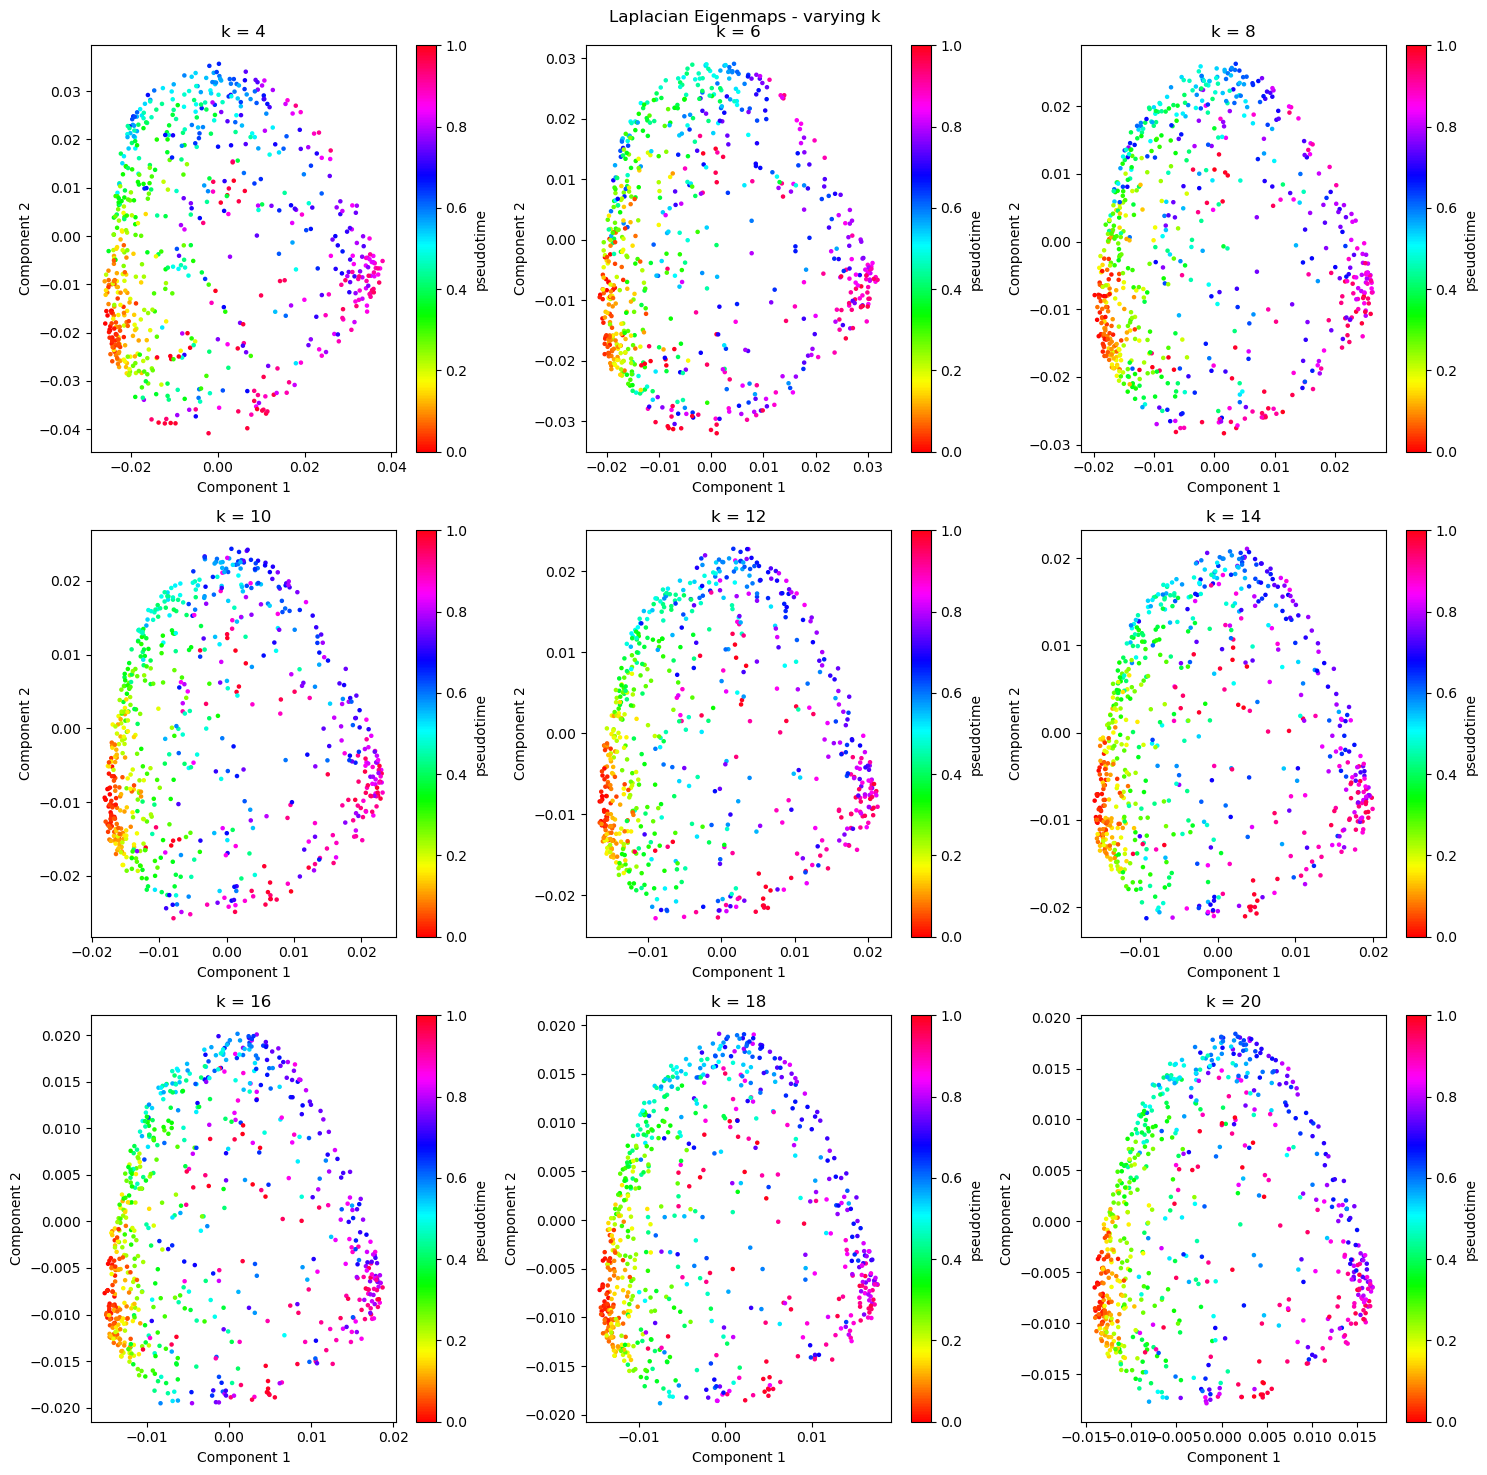

In [5]:
# embedding plots with varying k clusters in kNN

kVals = list(range(4, 22, 2))
fig, axes = plt.subplots(3, 3, figsize = (15, 15))
axes = axes.flatten()

for i, k in enumerate(kVals):
    embeddings, eigvals, ps = fullLaplacian(adata, k = k)
    newAdata = rankPseudo(adata, embeddings, ps)
    sc = axes[i].scatter(embeddings[:, 0], embeddings[:, 1], c = newAdata.obs["lpt_rank"], cmap = "hsv", s = 5)
    axes[i].set_title(f"k = {k}")
    axes[i].set_xlabel("Component 1")
    axes[i].set_ylabel("Component 2")
    plt.colorbar(sc, ax = axes[i], label = "pseudotime")

plt.suptitle("Laplacian Eigenmaps - varying k")
plt.tight_layout()
# fig.savefig("../../lapSubplots.png", dpi = 150, bbox_inches = "tight")
plt.show()

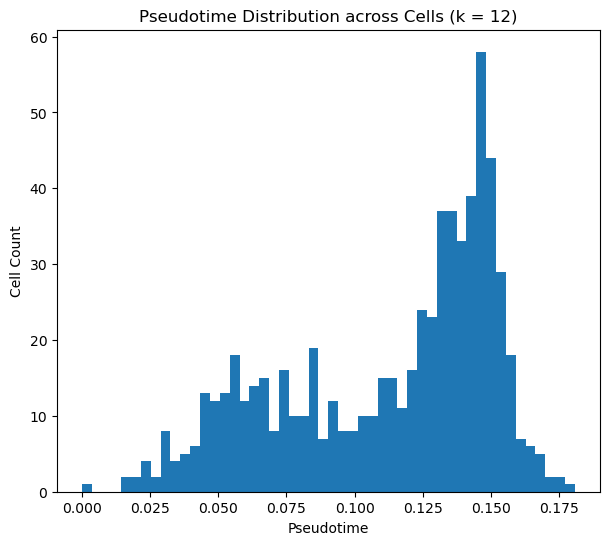

In [16]:
# plot of pseudotime distribution
embeddings, eigvals, pseudo = fullLaplacian(adata, k = 12, nComponents = 10)

plt.figure(figsize = (7, 6))
plt.hist(pseudo, bins = 50)
plt.xlabel("Pseudotime")
plt.ylabel("Cell Count")
plt.title(f"Pseudotime Distribution across Cells (k = 12)")
plt.show()

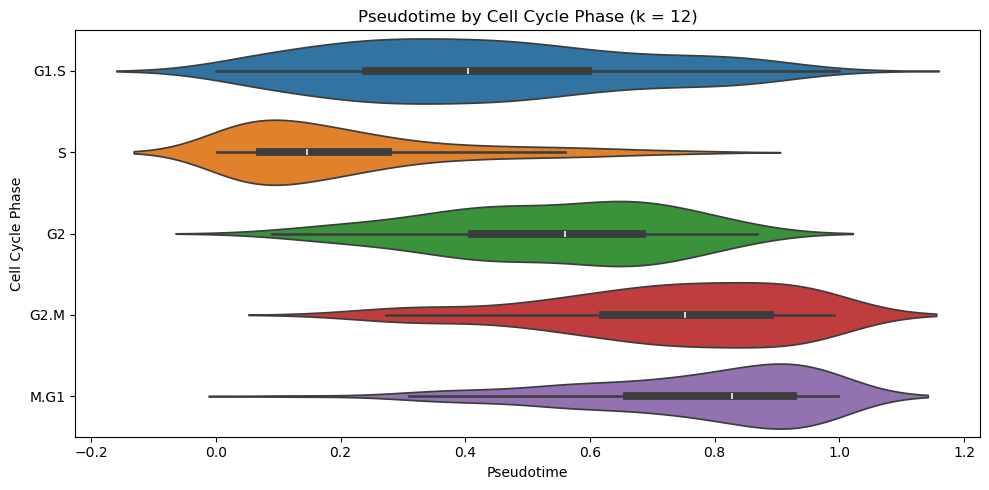

In [10]:
### cell cycle phase vs pseudotime of cells

# violin plot pseudotime vs cell cycle phase
fig, ax = plt.subplots(figsize = (10, 5))
sns.violinplot(data=adata.obs, x='lpt_rank',y='cc_phase',hue='cc_phase',ax=ax,palette='tab10')
ax.set_xlabel("Pseudotime")
ax.set_ylabel("Cell Cycle Phase")
ax.set_title("Pseudotime by Cell Cycle Phase (k = 12)")
plt.tight_layout()
plt.show()

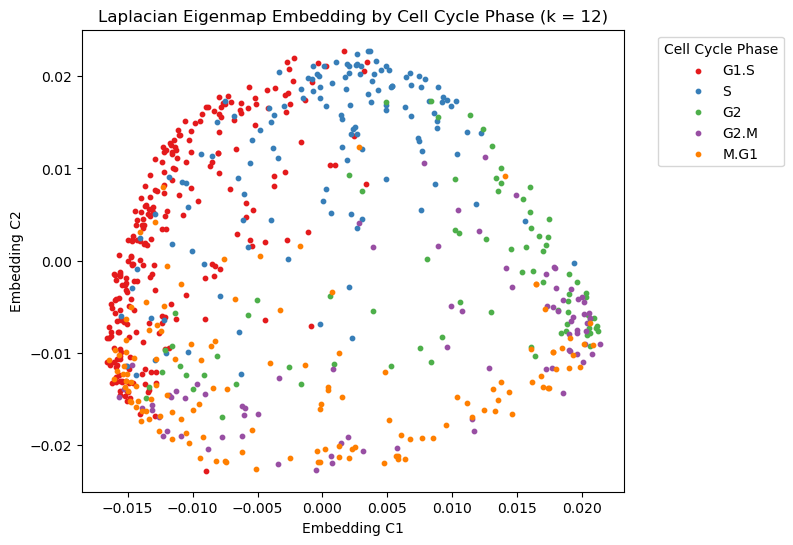

In [15]:
# circular embedding with cell cycle phase labels

phases = ["G1.S", "S", "G2", "G2.M", "M.G1"]
colors = sns.color_palette("Set1", len(phases))

fig, ax = plt.subplots(figsize = (7, 6))


for phase, color in zip(phases, colors):
    mask = adata.obs["cc_phase"] == phase
    ax.scatter(embeddings[mask, 0], embeddings[mask, 1], label = phase, color = color, s = 10)

ax.set_title("Laplacian Eigenmap Embedding by Cell Cycle Phase (k = 12)")
ax.set_xlabel("Embedding C1")
ax.set_ylabel("Embedding C2")
ax.legend(title = "Cell Cycle Phase", bbox_to_anchor = (1.05, 1), loc = "upper left")
fig.savefig("../../lapEmvsCC.png")
plt.show()